#Customer Engagement & Product Utilization Analytics for Retention Strategy

## Project Introduction

### In modern banking, customer retention is not just about money — it’s about behavior.

A customer may have:

High salary 💰
Large account balance 💳

…but still leave the bank due to:

Low engagement
Poor product usage
Weak relationship with the bank

## Goal of This Project

### We are trying to answer:

👉 What kind of customers stay with the bank?
👉 What behaviors lead to churn?
👉 How can banks identify risky customers early?

##STEP 1: DATA INGESTION & VALIDATION


Uploading Dataset

In [1]:
from google.colab import files
uploaded = files.upload()

Saving European_Bank.csv to European_Bank.csv


##1.1 Load Dataset

In [2]:
import pandas as pd

df = pd.read_csv('European_Bank.csv')

df.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


###Understand the Data

Number of rows (customers)
& Number of columns (features)

In [3]:
df. shape

(10000, 14)

Column names, Data type, Missing values

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


Average balance, Salary distribution, Age patterns

In [5]:
df.describe()

,Year,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.0,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,2025.0,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,0.0,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,2025.0,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2025.0,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,2025.0,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,2025.0,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,2025.0,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


##1.2 Validate Engagement and Product Fields

In [6]:
# Check product values
print("Unique values in NumOfProducts:")
print(df['NumOfProducts'].unique())

# Check engagement (activity)
print("\nUnique values in IsActiveMember:")
print(df['IsActiveMember'].unique())

Unique values in NumOfProducts:
[1 3 2 4]

Unique values in IsActiveMember:
[1 0]


##1.3 Ensure Binary Variables Consistency

In [7]:
# Check binary columns
binary_cols = ['HasCrCard', 'IsActiveMember', 'Exited']

for col in binary_cols:
    print(f"\nUnique values in {col}:")
    print(df[col].unique())


Unique values in HasCrCard:
[1 0]

Unique values in IsActiveMember:
[1 0]

Unique values in Exited:
[1 0]


Fix (Standardization)

In [8]:
df['HasCrCard'] = df['HasCrCard'].astype(int)
df['IsActiveMember'] = df['IsActiveMember'].astype(int)
df['Exited'] = df['Exited'].astype(int)

##1.4 Confirm Churn Labeling Accuracy

In [9]:
churn_distribution = df['Exited'].value_counts(normalize=True) * 100
print(churn_distribution)

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


##Final Validation Check

In [10]:
# Invalid product values
invalid_products = df[~df['NumOfProducts'].between(1, 4)]

# Invalid binary values
invalid_binary = df[
    (~df['HasCrCard'].isin([0,1])) |
    (~df['IsActiveMember'].isin([0,1])) |
    (~df['Exited'].isin([0,1]))
]

print("Invalid Product Rows:", len(invalid_products))
print("Invalid Binary Rows:", len(invalid_binary))

Invalid Product Rows: 0
Invalid Binary Rows: 0


##STEP 2: ENGAGEMENT CLASSIFICATION

## Objective

###Create customer engagement profiles based on:

Activity level, Product usage, Financial strength

These profiles help identify:

Loyal customers, At-risk customers, Hidden churn risks

##2.1 Active Engaged Customers

In [11]:
df['Active_Engaged'] = (
    (df['IsActiveMember'] == 1) &
    (df['NumOfProducts'] >= 2)
).astype(int)
print("Active Engaged:", df['Active_Engaged'].sum())

Active Engaged: 2588


##2.2 Inactive Disengaged Customers

In [12]:
df['Inactive_Disengaged'] = (
    (df['IsActiveMember'] == 0) &
    (df['NumOfProducts'] <= 1)
).astype(int)
print("Inactive Disengaged:", df['Inactive_Disengaged'].sum())

Inactive Disengaged: 2521


##2.3 Active but Low-Product Customers

In [13]:
df['Active_Low_Product'] = (
    (df['IsActiveMember'] == 1) &
    (df['NumOfProducts'] == 1)
).astype(int)
print("Active Low Product:", df['Active_Low_Product'].sum())

Active Low Product: 2563


##2.4 Inactive High-Balance Customers

In [14]:
df['Inactive_High_Balance'] = (
    (df['IsActiveMember'] == 0) &
    (df['Balance'] > 100000)
).astype(int)
print("Inactive High Balance:", df['Inactive_High_Balance'].sum())

Inactive High Balance: 2356


###Check Overlap

In [15]:
df[['Active_Engaged',
    'Inactive_Disengaged',
    'Active_Low_Product',
    'Inactive_High_Balance']].sum(axis=1).value_counts()

,count
1,6874
2,1577
0,1549


###Engagement categories are designed as behavioral flags and are not mutually exclusive. This allows identification of customers exhibiting multiple risk or engagement characteristics simultaneously, reflecting real-world banking behavior.

##STEP 3: PRODUCT UTILIZATION ANALYSIS

#Objective

##Understand how product usage affects customer retention

We will answer:

####Does having more products reduce churn?
####Are single-product customers risky?
####How strong is product depth as a retention driver?

##3.1 Churn Rate by Number of Products

####Groups customers by number of products
####Calculates churn rate for each group

In [16]:
product_churn = df.groupby('NumOfProducts')['Exited'].mean()

print(product_churn)

NumOfProducts
1    0.277144
2    0.075817
3    0.827068
4    1.000000
Name: Exited, dtype: float64


##Visualization

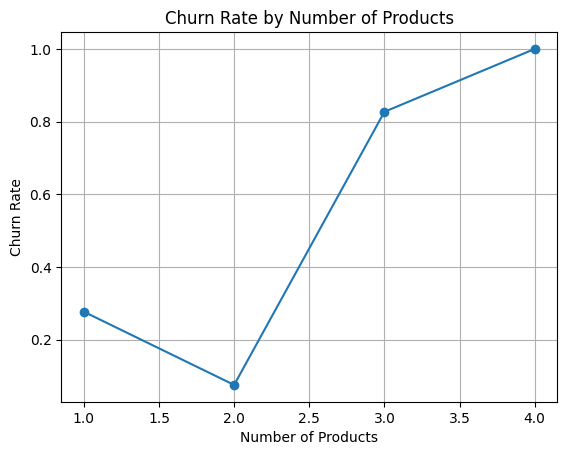

In [17]:
import matplotlib.pyplot as plt

product_churn.plot(kind='line', marker='o')
plt.title("Churn Rate by Number of Products")
plt.xlabel("Number of Products")
plt.ylabel("Churn Rate")
plt.grid()
plt.show()

##3.2 Single-Product vs Multi-Product Retention

###Create Category

In [18]:
df['ProductCategory'] = df['NumOfProducts'].apply(
    lambda x: 'Single Product' if x == 1 else 'Multi Product'
)

###Calculate Churn

In [19]:
single_vs_multi = df.groupby('ProductCategory')['Exited'].mean()

print(single_vs_multi)

ProductCategory
Multi Product     0.127746
Single Product    0.277144
Name: Exited, dtype: float64


###Visualization

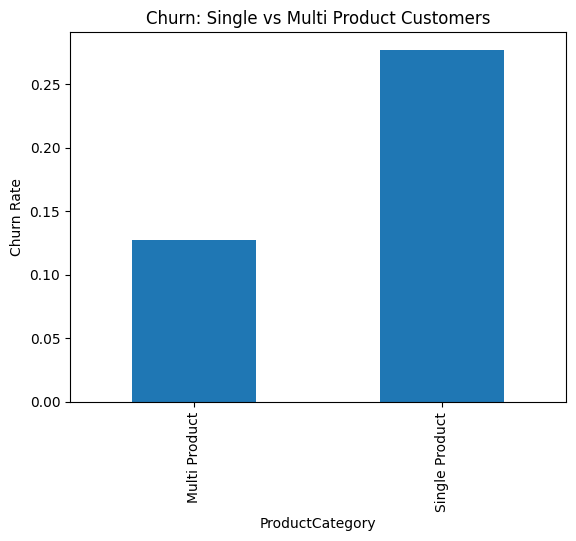

In [20]:
single_vs_multi.plot(kind='bar')
plt.title("Churn: Single vs Multi Product Customers")
plt.ylabel("Churn Rate")
plt.show()

##3.3 Product Depth vs Churn Relationship

###Objective

####Measure how depth of relationship (number of products) impacts churn

###Create Product Depth Index

In [21]:
df['ProductDepthIndex'] = df['NumOfProducts'] / df['NumOfProducts'].max()

###Group And Analyze

In [22]:
depth_churn = df.groupby('ProductDepthIndex')['Exited'].mean()

print(depth_churn)

ProductDepthIndex
0.25    0.277144
0.50    0.075817
0.75    0.827068
1.00    1.000000
Name: Exited, dtype: float64


###Visualization

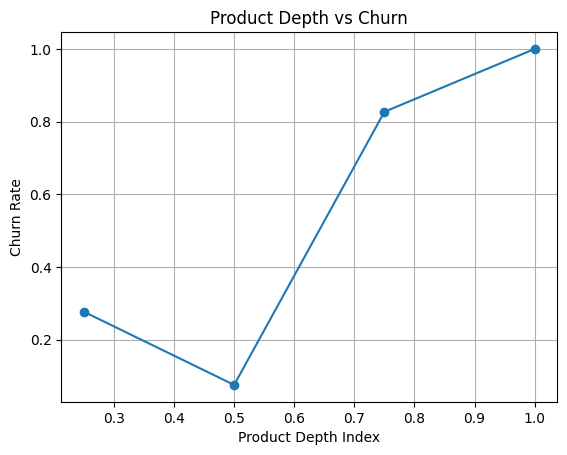

In [23]:
depth_churn.plot(kind='line', marker='o')
plt.title("Product Depth vs Churn")
plt.xlabel("Product Depth Index")
plt.ylabel("Churn Rate")
plt.grid()
plt.show()

##STEP 4: FINANCIAL COMMITMENT vs ENGAGEMENT ANALYSIS

###Objective

Identify customers who:

Have strong financial capacity 💰
But weak engagement ❌

👉 These are the most critical churn risks

##4.1 Balance vs Activity Cross-Analysis

In [24]:
balance_activity = df.groupby('IsActiveMember')['Balance'].mean()

print(balance_activity)

IsActiveMember
0    77134.376863
1    75875.422145
Name: Balance, dtype: float64


##Visualization

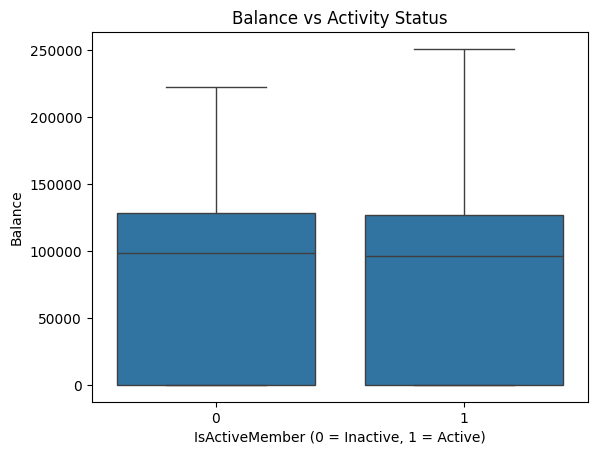

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='IsActiveMember', y='Balance', data=df)

plt.title("Balance vs Activity Status")
plt.xlabel("IsActiveMember (0 = Inactive, 1 = Active)")
plt.ylabel("Balance")
plt.show()

##Interpretation
####Compare average balance of:
####Active customers
####Inactive customers

👉 If inactive customers have high balance → risk signal

##4.2 Salary–Balance Mismatch Detection

##Objective

###Check whether:

####High earners are actually using the bank
####Or just keeping minimal balance

In [26]:
df['SalaryBalanceRatio'] = df['Balance'] / (df['EstimatedSalary'] + 1)

##Analyze Ratio

In [27]:
df['SalaryBalanceRatio'].describe()

,SalaryBalanceRatio
count,10000.000000
mean,3.790150
std,100.055758
min,0.000000
25%,0.000000
50%,0.746998
75%,1.514002
max,9770.883148


###Interpretation
####Low ratio → high salary, low usage → weak relationship
####High ratio → strong financial commitment

##4.3 Identify “At-Risk Premium Customers”

##Objective

###Find customers who:

####Have high balance 💰
####Are inactive ❌

👉 These are high-value churn risks

###Validate Count

In [28]:
df['AtRiskPremium'] = (
    (df['Balance'] > 100000) &
    (df['IsActiveMember'] == 0)
).astype(int)
df['AtRiskPremium'].value_counts()

,count
AtRiskPremium,
0,7644
1,2356


###Check Their Churn Behavior

In [29]:
df.groupby('AtRiskPremium')['Exited'].mean()

,Exited
AtRiskPremium,
0,0.165489
1,0.327674


##Interpretation
###If churn is higher for AtRiskPremium = 1
####👉 Confirms premium customers are at risk

#STEP 5: RETENTION STRENGTH ASSESSMENT

#Objective


##Evaluate how strong a customer’s relationship with the bank is, and identify:

####Loyal (“sticky”) customers
####Stability of retention across engagement levels
####Minimum engagement needed to reduce churn

##5.1 Define “Sticky Customer” Profiles

#Definition

##A sticky customer is:

####Active ✅
####Uses multiple products (≥ 2) ✅

👉 These customers are least likely to churn

In [30]:
df['StickyCustomer'] = (
    (df['IsActiveMember'] == 1) &
    (df['NumOfProducts'] >= 2)
).astype(int)
df['StickyCustomer'].value_counts()

,count
StickyCustomer,
0,7412
1,2588


##Interpretation

####1 → Strong relationship (loyal)
####0 → Weak/moderate relationship

##5.2 Measure Churn Stability Across Engagement Tiers

##Objective

###Check how churn behaves across different engagement levels

###Create Engagement Score

In [31]:
df['EngagementScore'] = (
    df['IsActiveMember'] * 0.6 +
    (df['NumOfProducts'] / df['NumOfProducts'].max()) * 0.4
)

###Create Engagement Tiers

In [32]:
df['EngagementTier'] = pd.cut(
    df['EngagementScore'],
    bins=4,
    labels=['Low', 'Medium', 'High', 'Very High']
)

###Analyze Churn per Tier

In [33]:
tier_churn = df.groupby('EngagementTier')['Exited'].mean()

print(tier_churn)

EngagementTier
Low          0.263802
Medium       1.000000
High         0.189231
Very High    0.096600
Name: Exited, dtype: float64


/tmp/ipykernel_10336/417330489.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tier_churn = df.groupby('EngagementTier')['Exited'].mean()


###Visualization

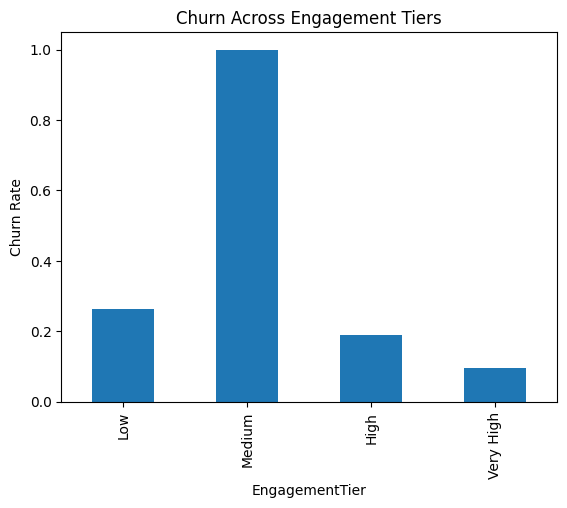

In [34]:
tier_churn.plot(kind='bar')
plt.title("Churn Across Engagement Tiers")
plt.ylabel("Churn Rate")
plt.show()

##Interpretation

###Churn should decrease as engagement increases
###Confirms engagement → retention relationship

##5.3 Identify Engagement Thresholds Linked to Retention

##Objective

###Find the minimum engagement level where churn drops significantly

In [35]:
threshold_analysis = df.groupby('EngagementTier')['Exited'].mean()

print(threshold_analysis)

EngagementTier
Low          0.263802
Medium       1.000000
High         0.189231
Very High    0.096600
Name: Exited, dtype: float64


/tmp/ipykernel_10336/1430903126.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  threshold_analysis = df.groupby('EngagementTier')['Exited'].mean()


##Interpretation
###Identify where churn sharply declines
###Example:
####High → low churn
####Medium → moderate churn

👉 This becomes your retention threshold

##(Important KPI) Relationship Strength Index

In [36]:
df['RelationshipStrength'] = (
    df['EngagementScore'] * 0.7 +
    (df['NumOfProducts'] / df['NumOfProducts'].max()) * 0.3
)
df[['EngagementScore', 'NumOfProducts', 'RelationshipStrength']].head()

,EngagementScore,NumOfProducts,RelationshipStrength
0,0.7,1,0.565
1,0.7,1,0.565
2,0.3,3,0.435
3,0.2,2,0.290
4,0.7,1,0.565


###Check Summary

In [37]:
df['RelationshipStrength'].describe()

,RelationshipStrength
count,10000.000000
mean,0.438221
std,0.226975
min,0.145000
25%,0.145000
50%,0.565000
75%,0.710000
max,1.000000


###Save Dataset

In [38]:
df.to_csv('final_data.csv', index=False)

###Download

In [39]:
from google.colab import files
files.download('final_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>